In [11]:
import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import numpy as np

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
import insertHybrid
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict

seed = 6
random.seed(seed)
np.random.seed(seed)

In [12]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 3)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5   #### hier kann die ANzahl der durchschnittlichen Kinder ausgewählt werden
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, pruned_gene_tree)
# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

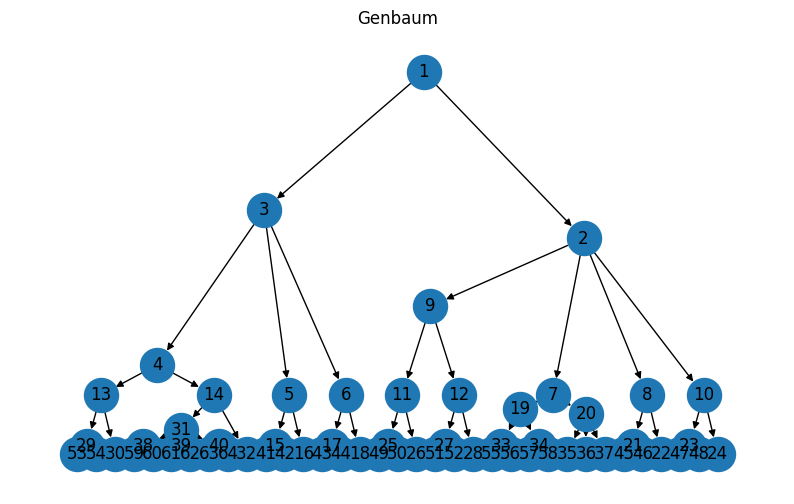

[(1, {'label': 1, 'event': 'D', 'reconc': (0, 1), 'tstamp': 1.5235733179672213, 'transferred': 0, 'dist': 0.0}), (3, {'label': 3, 'event': 'D', 'reconc': (0, 1), 'tstamp': 0.9740825825144075, 'transferred': 0, 'dist': np.float64(0.317966216130722), 'sibling_nr': 0}), (4, {'label': 4, 'event': 'D', 'reconc': (0, 1), 'tstamp': 0.35624623046188486, 'transferred': 0, 'dist': np.float64(2.0428077428902034), 'sibling_nr': 0}), (13, {'label': 13, 'event': 'S', 'reconc': 1, 'tstamp': 0.234924363637933, 'transferred': 0, 'dist': np.float64(0.10322117478419592), 'sibling_nr': 0}), (29, {'label': 29, 'event': 'S', 'reconc': 2, 'tstamp': 0.03320592647923659, 'transferred': 0, 'dist': np.float64(0.16462871147806515), 'sibling_nr': 0}), (53, {'label': 53, 'event': 'S', 'reconc': 4, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.07628347290520061), 'sibling_nr': 0}), (54, {'label': 54, 'event': 'S', 'reconc': 5, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.02156247248726348), 'sibling

In [13]:
N = insertHybrid.convert_to_nx(pruned_gene_tree)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

print(N.nodes(data = True))

Es wurde ein Hybrid zwischen node 15 und node 41 eingefügt und dieser wurde mit Node 18 verbunden
Es wurde ein Hybrid zwischen node 65 und node 41 eingefügt und dieser wurde mit Node 46 verbunden
Es wurde ein Hybrid zwischen node 23 und node 47 eingefügt und dieser wurde mit Node 56 verbunden
Es wurde ein Hybrid zwischen node 9 und node 12 eingefügt und dieser wurde mit Node 54 verbunden
Es wurde ein Hybrid zwischen node 27 und node 51 eingefügt und dieser wurde mit Node 44 verbunden
Es wurde ein Hybrid zwischen node 5 und node 16 eingefügt und dieser wurde mit Node 52 verbunden
Es wurde ein Hybrid zwischen node 33 und node 56 eingefügt und dieser wurde mit Node 28 verbunden
Es wurde ein Hybrid zwischen node 4 und node 13 eingefügt und dieser wurde mit Node 23 verbunden
Es wurde ein Hybrid zwischen node 2 und node 8 eingefügt und dieser wurde mit Node 61 verbunden
Es wurde ein Hybrid zwischen node 39 und node 61 eingefügt und dieser wurde mit Node 47 verbunden


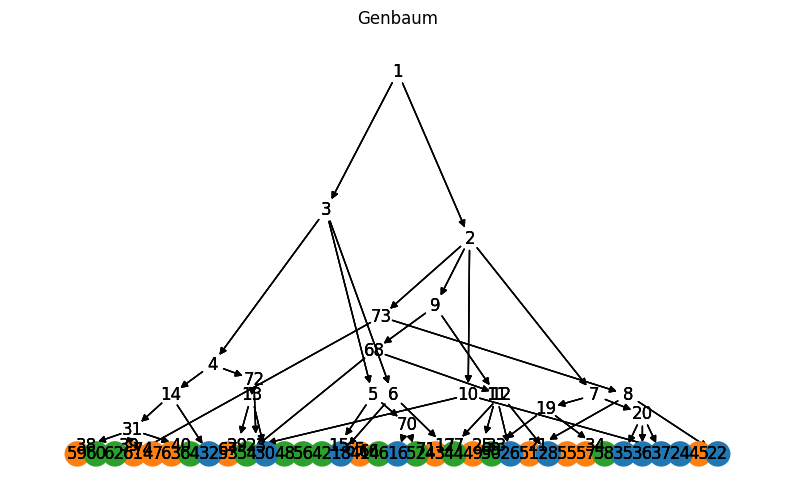

In [14]:
N = insertHybrid.insertHybrid(N,10)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for color, node_list in color_to_keys.items():
    nx.draw(N,
            pos,
            nodelist=node_list,
            node_color=[color] * len(node_list),
            with_labels=True)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)

False


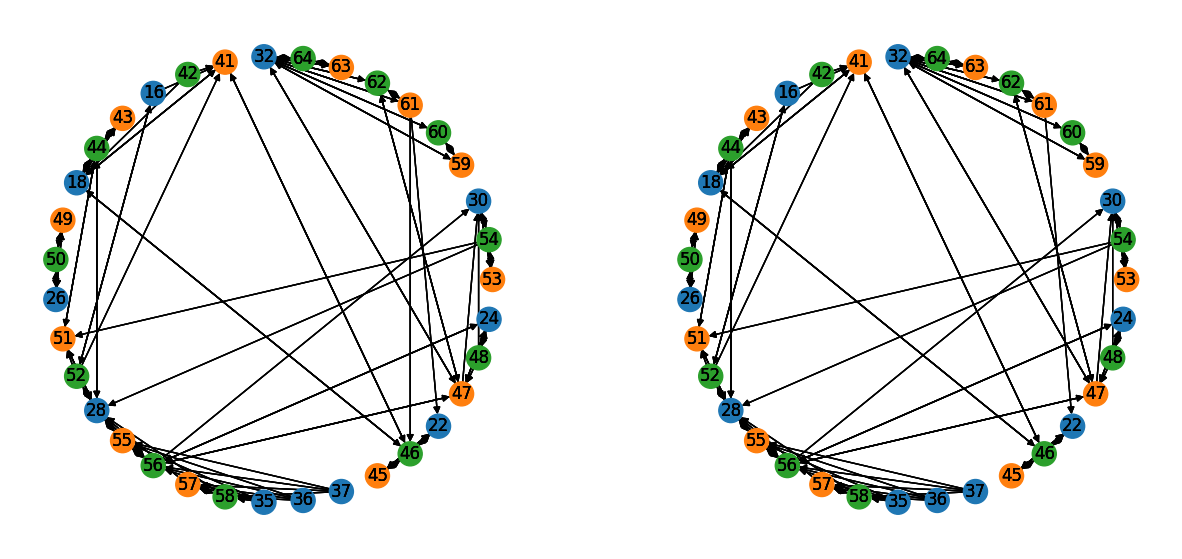

In [15]:
G = insertHybrid.bmg(N)
G_strong = insertHybrid.bmg(N,"strong")

print(nx.utils.graphs_equal(G, G_strong))

ig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Tree BMG
for color, node_list in color_to_keys.items():
    nx.draw(G, nx.circular_layout(G), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[0], with_labels=True)
# network BMG
for color, node_list in color_to_keys.items():
    nx.draw(G_strong, nx.circular_layout(G_strong), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[1], with_labels=True)